In [1]:
# ============================================
# PROJECT 2: Late Delivery Risk Prediction
# Phase 4: Exploratory Data Analysis (EDA)
# Author: Mohan | Unified Mentor Internship
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Professional chart styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Custom color palette (professional, colorblind-friendly)
COLORS = {
    'late': '#e74c3c',       # red
    'ontime': '#2ecc71',     # green
    'primary': '#3498db',    # blue
    'secondary': '#f39c12',  # orange
    'accent': '#9b59b6'      # purple
}

# Load CLEANED dataset (from Phase 3)
df = pd.read_csv('../data/APL_Logistics_cleaned.csv')

print(f"✅ Cleaned dataset loaded")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🎯 Target distribution: {df['Late_delivery_risk'].value_counts().to_dict()}")

✅ Cleaned dataset loaded
📊 Shape: 180,519 rows × 24 columns
🎯 Target distribution: {1: 98977, 0: 81542}


In [2]:
# Verify columns
print("Columns in cleaned dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

Columns in cleaned dataset:
 1. Type
 2. Days for shipment (scheduled)
 3. Benefit per order
 4. Sales per customer
 5. Late_delivery_risk
 6. Category Name
 7. Customer Country
 8. Customer Segment
 9. Department Name
10. Latitude
11. Longitude
12. Market
13. Order Country
14. Order Item Discount
15. Order Item Discount Rate
16. Order Item Product Price
17. Order Item Profit Ratio
18. Order Item Quantity
19. Sales
20. Order Item Total
21. Order Profit Per Order
22. Order Region
23. Product Price
24. Shipping Mode


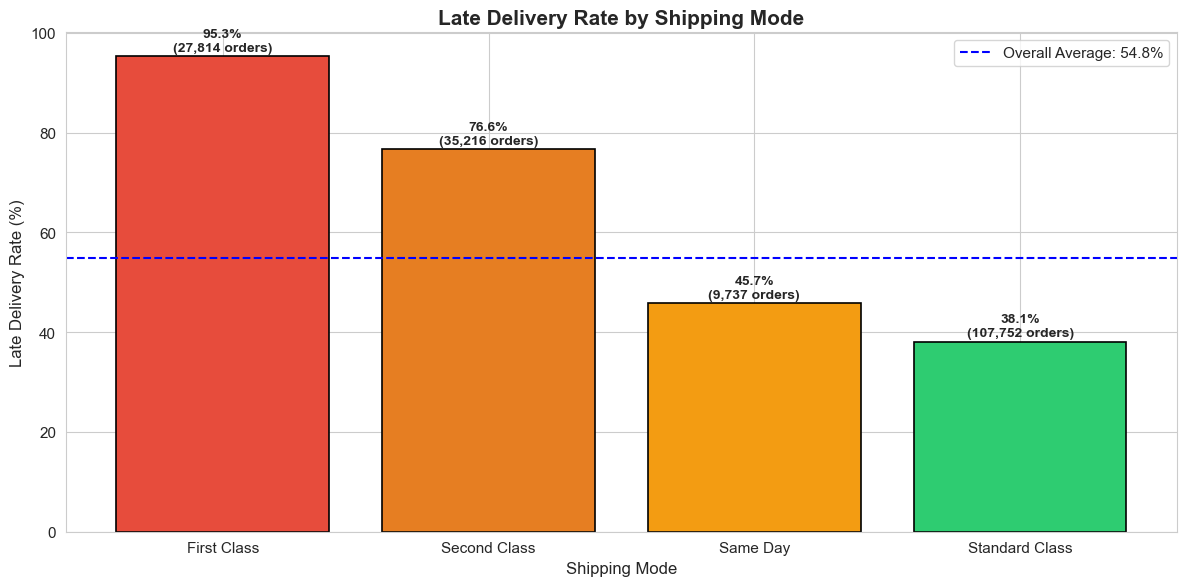


💡 INSIGHT:
 Shipping Mode  late_pct  count
   First Class 95.322499  27814
  Second Class 76.632781  35216
      Same Day 45.743042   9737
Standard Class 38.071683 107752

🌟 Power BI tip: Use this as a slicer on Page 2 of your dashboard


In [3]:
# ===== CHART 1: Late Delivery Rate by Shipping Mode =====
# Business question: Which shipping mode is most risky?

fig, ax = plt.subplots(figsize=(12, 6))

shipping_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
shipping_risk['late_pct'] = shipping_risk['mean'] * 100
shipping_risk = shipping_risk.sort_values('late_pct', ascending=False)

bars = ax.bar(shipping_risk['Shipping Mode'], shipping_risk['late_pct'], 
              color=[COLORS['late'], '#e67e22', COLORS['secondary'], COLORS['ontime']],
              edgecolor='black', linewidth=1.2)

ax.set_title('Late Delivery Rate by Shipping Mode', fontsize=15, fontweight='bold')
ax.set_xlabel('Shipping Mode', fontsize=12)
ax.set_ylabel('Late Delivery Rate (%)', fontsize=12)
ax.axhline(y=df['Late_delivery_risk'].mean()*100, color='blue', linestyle='--', 
           label=f'Overall Average: {df["Late_delivery_risk"].mean()*100:.1f}%')
ax.legend()

# Add data labels on bars
for bar, count in zip(bars, shipping_risk['count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%\n({count:,} orders)', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/03_late_rate_by_shipping_mode.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT:")
print(shipping_risk[['Shipping Mode', 'late_pct', 'count']].to_string(index=False))
print("\n🌟 Power BI tip: Use this as a slicer on Page 2 of your dashboard")

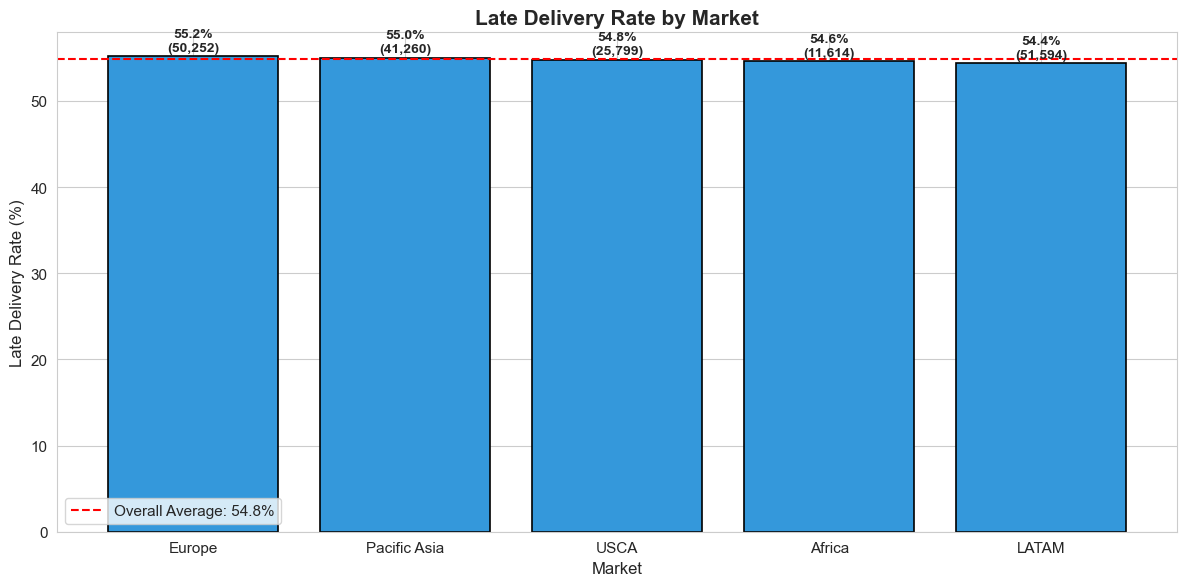


💡 INSIGHT:
      Market  late_pct  count
      Europe 55.207753  50252
Pacific Asia 55.046049  41260
        USCA 54.800574  25799
      Africa 54.589289  11614
       LATAM 54.355158  51594


In [4]:
# ===== CHART 2: Late Delivery Rate by Market =====
# Business question: Which global markets are most affected?

fig, ax = plt.subplots(figsize=(12, 6))

market_risk = df.groupby('Market')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
market_risk['late_pct'] = market_risk['mean'] * 100
market_risk = market_risk.sort_values('late_pct', ascending=False)

bars = ax.bar(market_risk['Market'], market_risk['late_pct'],
              color=COLORS['primary'], edgecolor='black', linewidth=1.2)

ax.set_title('Late Delivery Rate by Market', fontsize=15, fontweight='bold')
ax.set_xlabel('Market', fontsize=12)
ax.set_ylabel('Late Delivery Rate (%)', fontsize=12)
ax.axhline(y=df['Late_delivery_risk'].mean()*100, color='red', linestyle='--',
           label=f'Overall Average: {df["Late_delivery_risk"].mean()*100:.1f}%')
ax.legend()

for bar, count in zip(bars, market_risk['count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{height:.1f}%\n({count:,})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/04_late_rate_by_market.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT:")
print(market_risk[['Market', 'late_pct', 'count']].to_string(index=False))

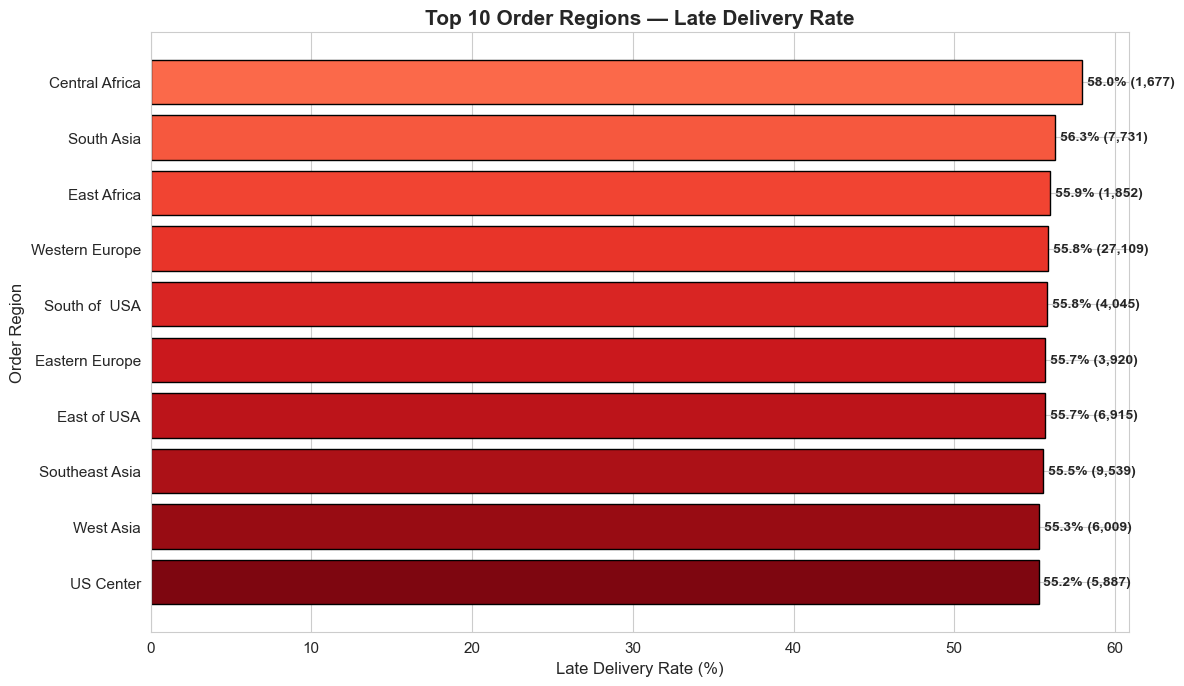


💡 INSIGHT: These regions need URGENT operational intervention


In [5]:
# ===== CHART 3: Top 10 Order Regions by Late Rate =====
# Business question: Which specific regions are hotspots?

fig, ax = plt.subplots(figsize=(12, 7))

region_risk = df.groupby('Order Region')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
region_risk = region_risk[region_risk['count'] > 1000]  # Filter low-volume regions
region_risk['late_pct'] = region_risk['mean'] * 100
region_risk = region_risk.sort_values('late_pct', ascending=False).head(10)

colors_gradient = plt.cm.Reds(np.linspace(0.5, 0.95, len(region_risk)))
bars = ax.barh(region_risk['Order Region'], region_risk['late_pct'],
               color=colors_gradient, edgecolor='black', linewidth=1)

ax.set_title('Top 10 Order Regions — Late Delivery Rate', fontsize=15, fontweight='bold')
ax.set_xlabel('Late Delivery Rate (%)', fontsize=12)
ax.set_ylabel('Order Region', fontsize=12)
ax.invert_yaxis()

for bar, count in zip(bars, region_risk['count']):
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}% ({count:,})',
            ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/05_top_regions_late_rate.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: These regions need URGENT operational intervention")

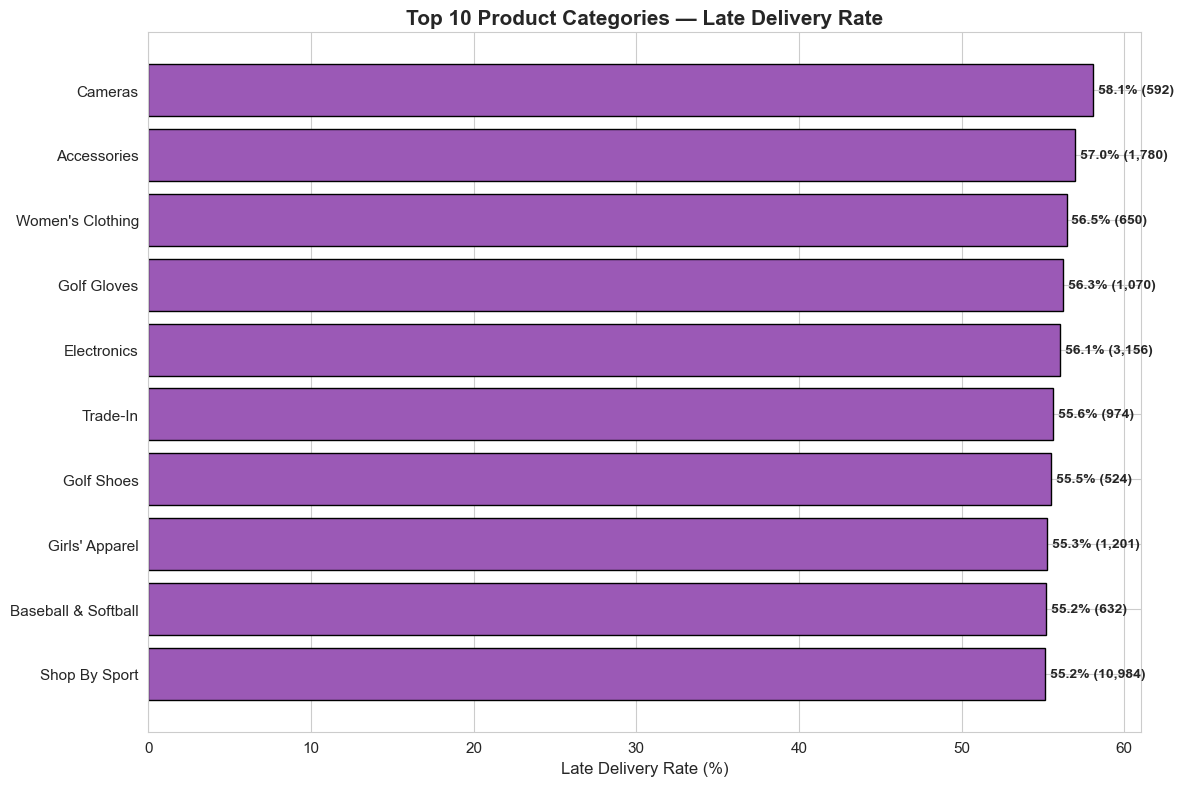

In [6]:
# ===== CHART 4: Late Delivery Rate by Category =====
# Business question: Are certain products more risky?

fig, ax = plt.subplots(figsize=(12, 8))

cat_risk = df.groupby('Category Name')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
cat_risk = cat_risk[cat_risk['count'] > 500]  # Filter low-volume categories
cat_risk['late_pct'] = cat_risk['mean'] * 100
cat_risk = cat_risk.sort_values('late_pct', ascending=False).head(10)

bars = ax.barh(cat_risk['Category Name'], cat_risk['late_pct'],
               color=COLORS['accent'], edgecolor='black', linewidth=1)

ax.set_title('Top 10 Product Categories — Late Delivery Rate', fontsize=15, fontweight='bold')
ax.set_xlabel('Late Delivery Rate (%)', fontsize=12)
ax.invert_yaxis()

for bar, count in zip(bars, cat_risk['count']):
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}% ({count:,})',
            ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/06_top_categories_late_rate.png', dpi=300, bbox_inches='tight')
plt.show()

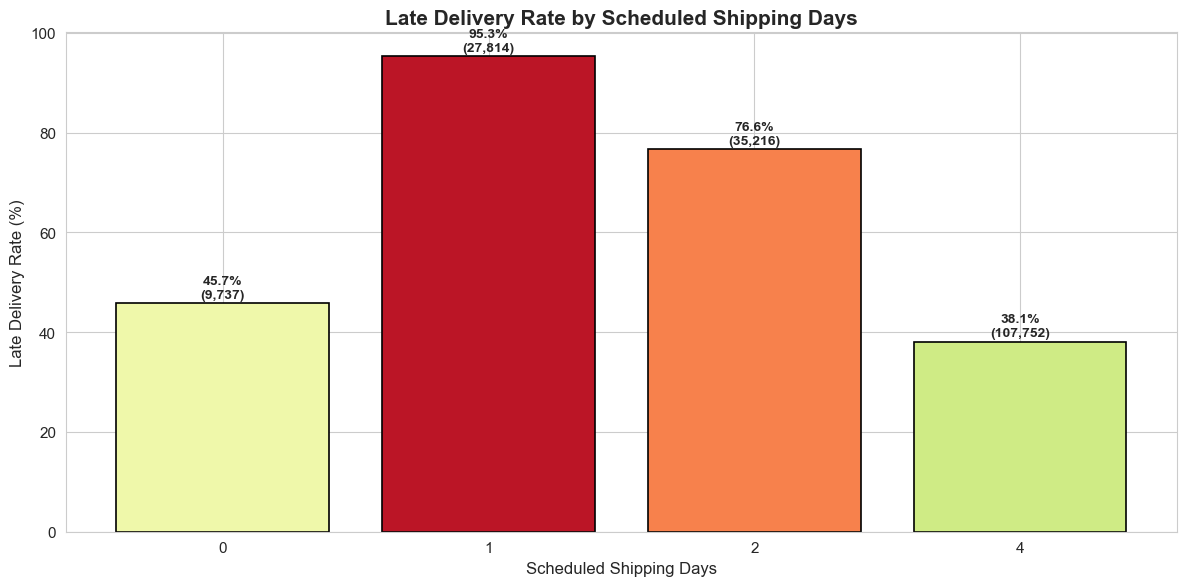


💡 INSIGHT: Tighter schedules (1-2 days) likely have higher risk
This is exactly the kind of pattern ML can learn!


In [7]:
# ===== CHART 5: Scheduled Days vs Late Rate =====
# Business question: Do tighter schedules cause more delays?

fig, ax = plt.subplots(figsize=(12, 6))

days_risk = df.groupby('Days for shipment (scheduled)')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
days_risk['late_pct'] = days_risk['mean'] * 100

bars = ax.bar(days_risk['Days for shipment (scheduled)'].astype(str), days_risk['late_pct'],
              color=plt.cm.RdYlGn_r(days_risk['late_pct']/100),
              edgecolor='black', linewidth=1.2)

ax.set_title('Late Delivery Rate by Scheduled Shipping Days', fontsize=15, fontweight='bold')
ax.set_xlabel('Scheduled Shipping Days', fontsize=12)
ax.set_ylabel('Late Delivery Rate (%)', fontsize=12)

for bar, count in zip(bars, days_risk['count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%\n({count:,})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/07_scheduled_days_vs_late.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Tighter schedules (1-2 days) likely have higher risk")
print("This is exactly the kind of pattern ML can learn!")

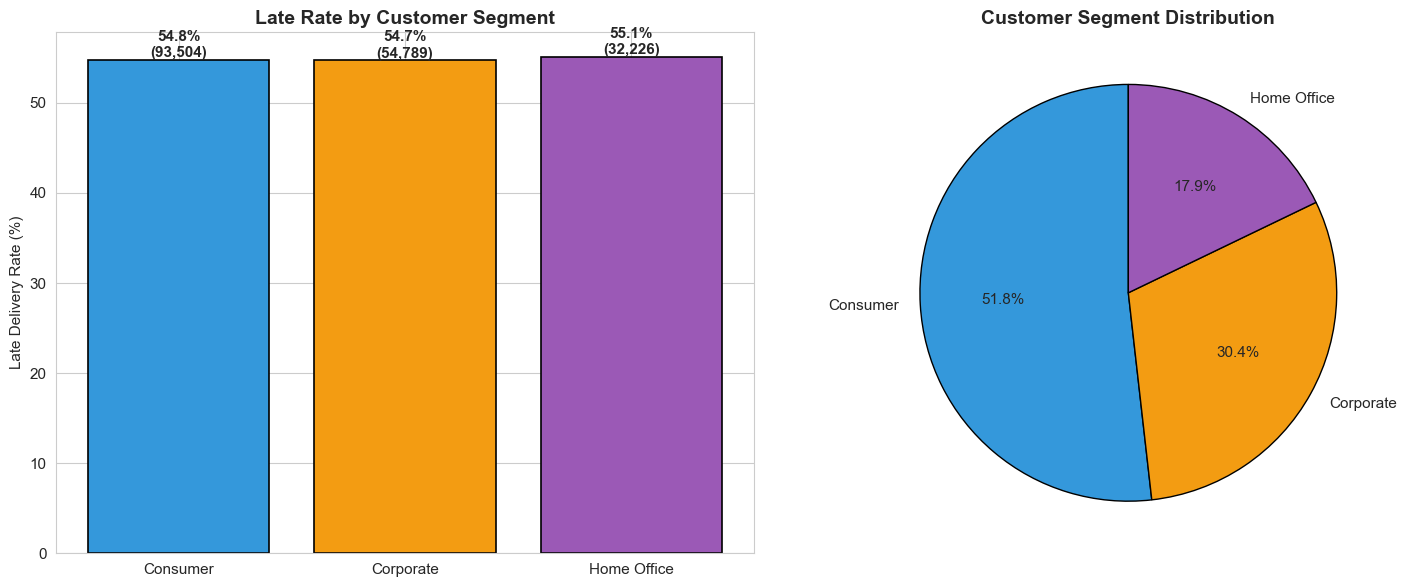

In [8]:
# ===== CHART 6: Late Rate by Customer Segment =====

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart: late rate by segment
seg_risk = df.groupby('Customer Segment')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
seg_risk['late_pct'] = seg_risk['mean'] * 100

axes[0].bar(seg_risk['Customer Segment'], seg_risk['late_pct'],
            color=[COLORS['primary'], COLORS['secondary'], COLORS['accent']],
            edgecolor='black', linewidth=1.2)
axes[0].set_title('Late Rate by Customer Segment', fontweight='bold')
axes[0].set_ylabel('Late Delivery Rate (%)')
for i, (pct, count) in enumerate(zip(seg_risk['late_pct'], seg_risk['count'])):
    axes[0].text(i, pct + 0.3, f'{pct:.1f}%\n({count:,})',
                 ha='center', fontweight='bold')

# Pie: segment distribution
axes[1].pie(seg_risk['count'], labels=seg_risk['Customer Segment'],
            colors=[COLORS['primary'], COLORS['secondary'], COLORS['accent']],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Customer Segment Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/08_customer_segment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

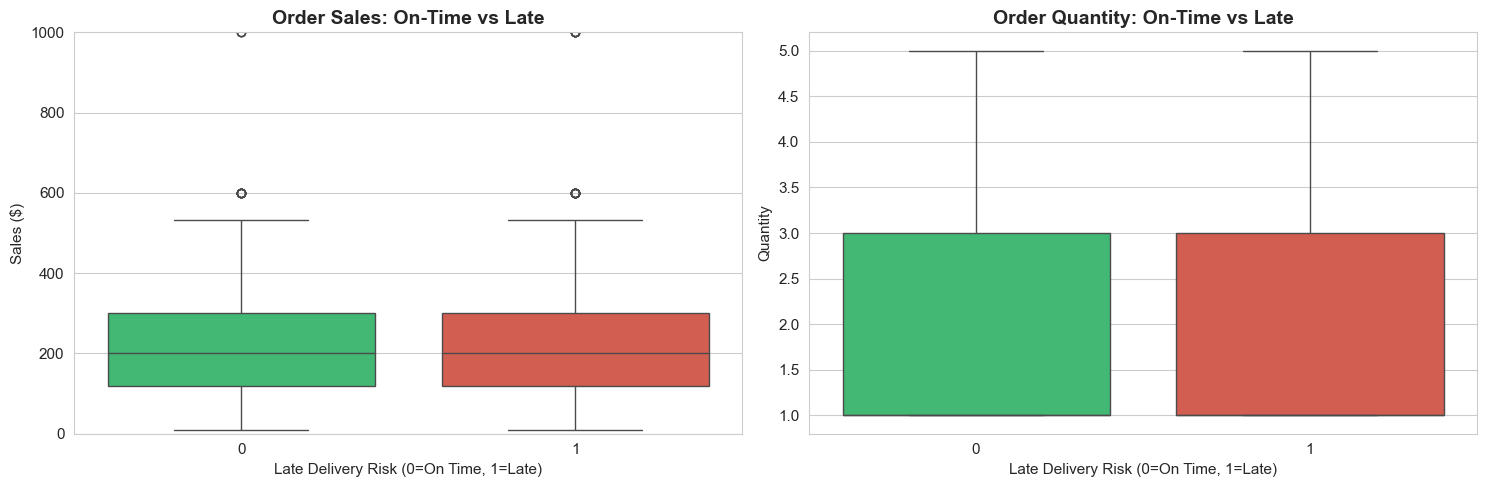


💡 INSIGHT: Comparing distributions tells us if order size impacts delays


In [9]:
# ===== CHART 7: Order Value Distribution by Late/On-Time =====

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(data=df, x='Late_delivery_risk', y='Sales', 
            ax=axes[0], palette=[COLORS['ontime'], COLORS['late']])
axes[0].set_title('Order Sales: On-Time vs Late', fontweight='bold')
axes[0].set_xlabel('Late Delivery Risk (0=On Time, 1=Late)')
axes[0].set_ylabel('Sales ($)')
axes[0].set_ylim(0, 1000)  # Zoom into typical range

# Boxplot for Order Item Quantity
sns.boxplot(data=df, x='Late_delivery_risk', y='Order Item Quantity',
            ax=axes[1], palette=[COLORS['ontime'], COLORS['late']])
axes[1].set_title('Order Quantity: On-Time vs Late', fontweight='bold')
axes[1].set_xlabel('Late Delivery Risk (0=On Time, 1=Late)')
axes[1].set_ylabel('Quantity')

plt.tight_layout()
plt.savefig('../charts/09_order_value_vs_late.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Comparing distributions tells us if order size impacts delays")

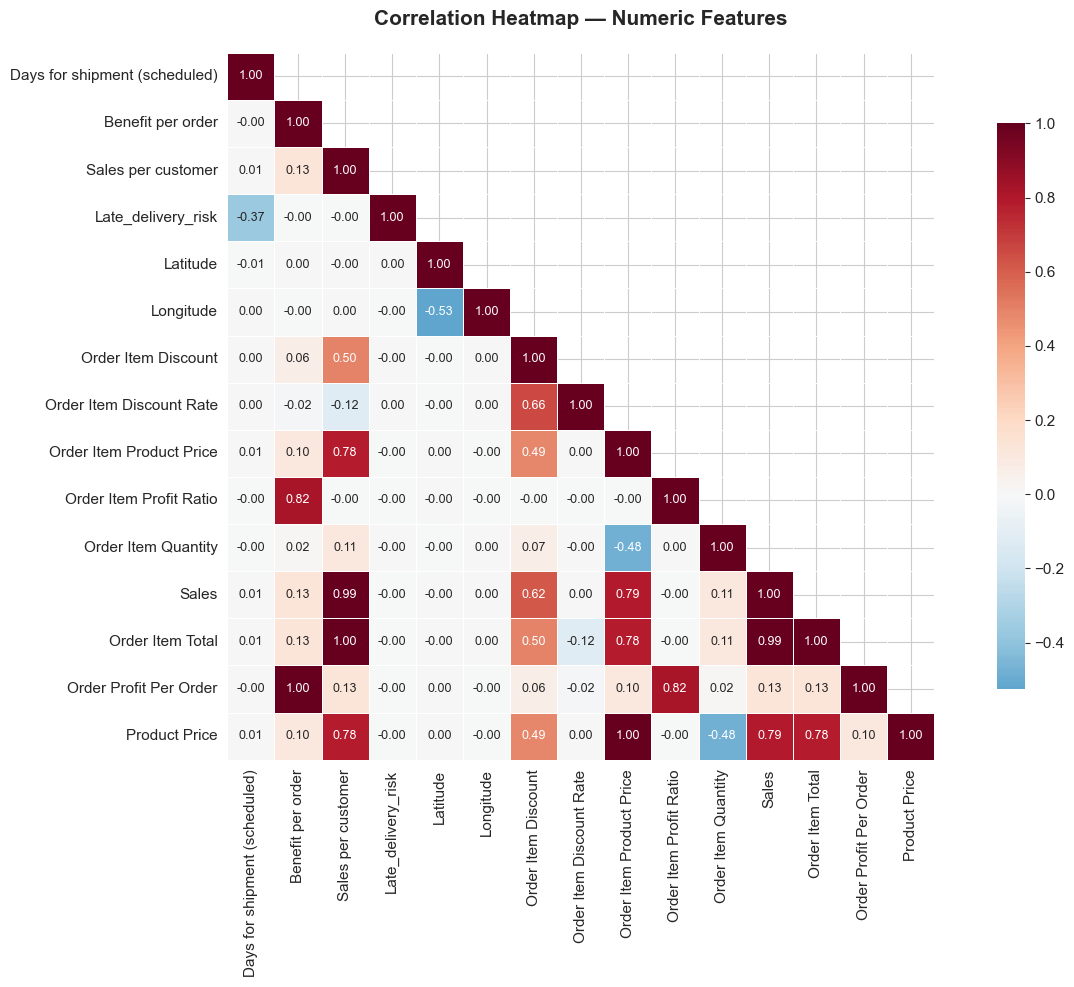


💡 Top correlations with Late_delivery_risk:
Late_delivery_risk               1.000000
Days for shipment (scheduled)    0.369352
Order Item Total                 0.003791
Sales per customer               0.003791
Benefit per order                0.003727
Order Profit Per Order           0.003727
Sales                            0.003564
Order Item Profit Ratio          0.002316
Order Item Product Price         0.002175
Product Price                    0.002175
Name: Late_delivery_risk, dtype: float64


In [10]:
# ===== CHART 8: Correlation Heatmap =====
# Business question: Which numeric features correlate with late delivery?

fig, ax = plt.subplots(figsize=(14, 10))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # Upper triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})

ax.set_title('Correlation Heatmap — Numeric Features', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../charts/10_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations with target
print("\n💡 Top correlations with Late_delivery_risk:")
target_corr = corr['Late_delivery_risk'].abs().sort_values(ascending=False)
print(target_corr.head(10))

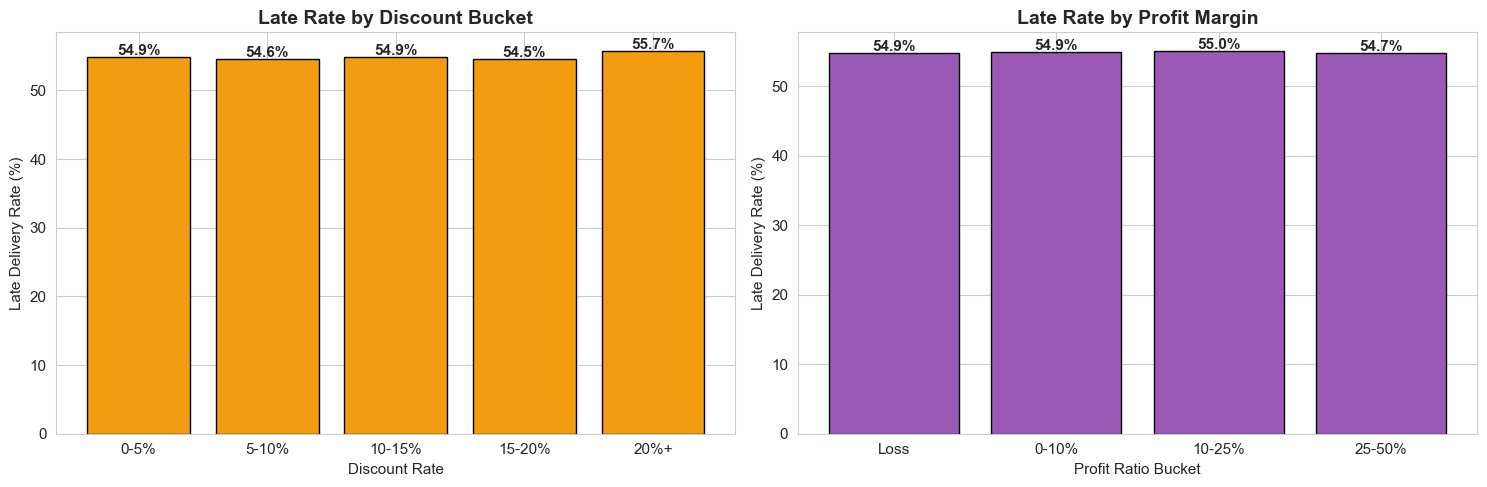

In [11]:
# ===== CHART 9: Discount Rate vs Late Delivery =====

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Create discount buckets
df['Discount_Bucket'] = pd.cut(df['Order Item Discount Rate'], 
                                bins=[0, 0.05, 0.10, 0.15, 0.20, 0.30],
                                labels=['0-5%', '5-10%', '10-15%', '15-20%', '20%+'])

discount_risk = df.groupby('Discount_Bucket')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
discount_risk['late_pct'] = discount_risk['mean'] * 100

axes[0].bar(discount_risk['Discount_Bucket'].astype(str), discount_risk['late_pct'],
            color=COLORS['secondary'], edgecolor='black')
axes[0].set_title('Late Rate by Discount Bucket', fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Late Delivery Rate (%)')

for i, (pct, count) in enumerate(zip(discount_risk['late_pct'], discount_risk['count'])):
    if not pd.isna(pct):
        axes[0].text(i, pct + 0.3, f'{pct:.1f}%', ha='center', fontweight='bold')

# Profit ratio impact
df['Profit_Bucket'] = pd.cut(df['Order Item Profit Ratio'],
                              bins=[-3, 0, 0.1, 0.25, 0.5, 1.0],
                              labels=['Loss', '0-10%', '10-25%', '25-50%', '50%+'])

profit_risk = df.groupby('Profit_Bucket')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
profit_risk['late_pct'] = profit_risk['mean'] * 100

axes[1].bar(profit_risk['Profit_Bucket'].astype(str), profit_risk['late_pct'],
            color=COLORS['accent'], edgecolor='black')
axes[1].set_title('Late Rate by Profit Margin', fontweight='bold')
axes[1].set_xlabel('Profit Ratio Bucket')
axes[1].set_ylabel('Late Delivery Rate (%)')

for i, (pct, count) in enumerate(zip(profit_risk['late_pct'], profit_risk['count'])):
    if not pd.isna(pct):
        axes[1].text(i, pct + 0.3, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/11_discount_profit_impact.png', dpi=300, bbox_inches='tight')
plt.show()

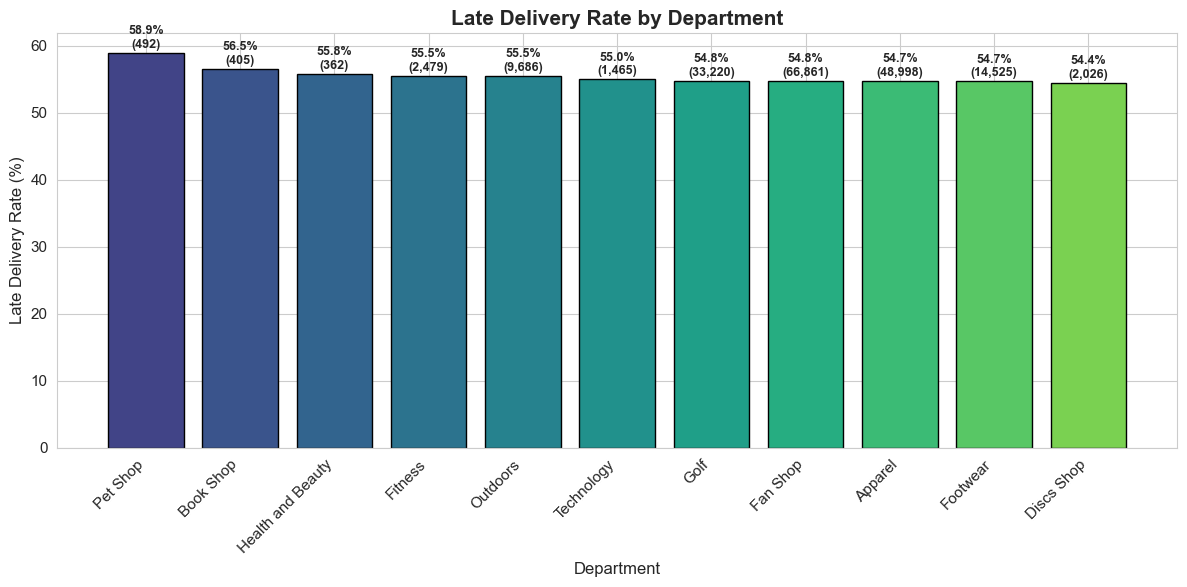

In [12]:
# ===== CHART 10: Late Rate by Department =====

fig, ax = plt.subplots(figsize=(12, 6))

dept_risk = df.groupby('Department Name')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
dept_risk['late_pct'] = dept_risk['mean'] * 100
dept_risk = dept_risk.sort_values('late_pct', ascending=False)

bars = ax.bar(dept_risk['Department Name'], dept_risk['late_pct'],
              color=plt.cm.viridis(np.linspace(0.2, 0.8, len(dept_risk))),
              edgecolor='black')

ax.set_title('Late Delivery Rate by Department', fontsize=15, fontweight='bold')
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Late Delivery Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, dept_risk['count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{height:.1f}%\n({count:,})',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../charts/12_late_rate_by_department.png', dpi=300, bbox_inches='tight')
plt.show()

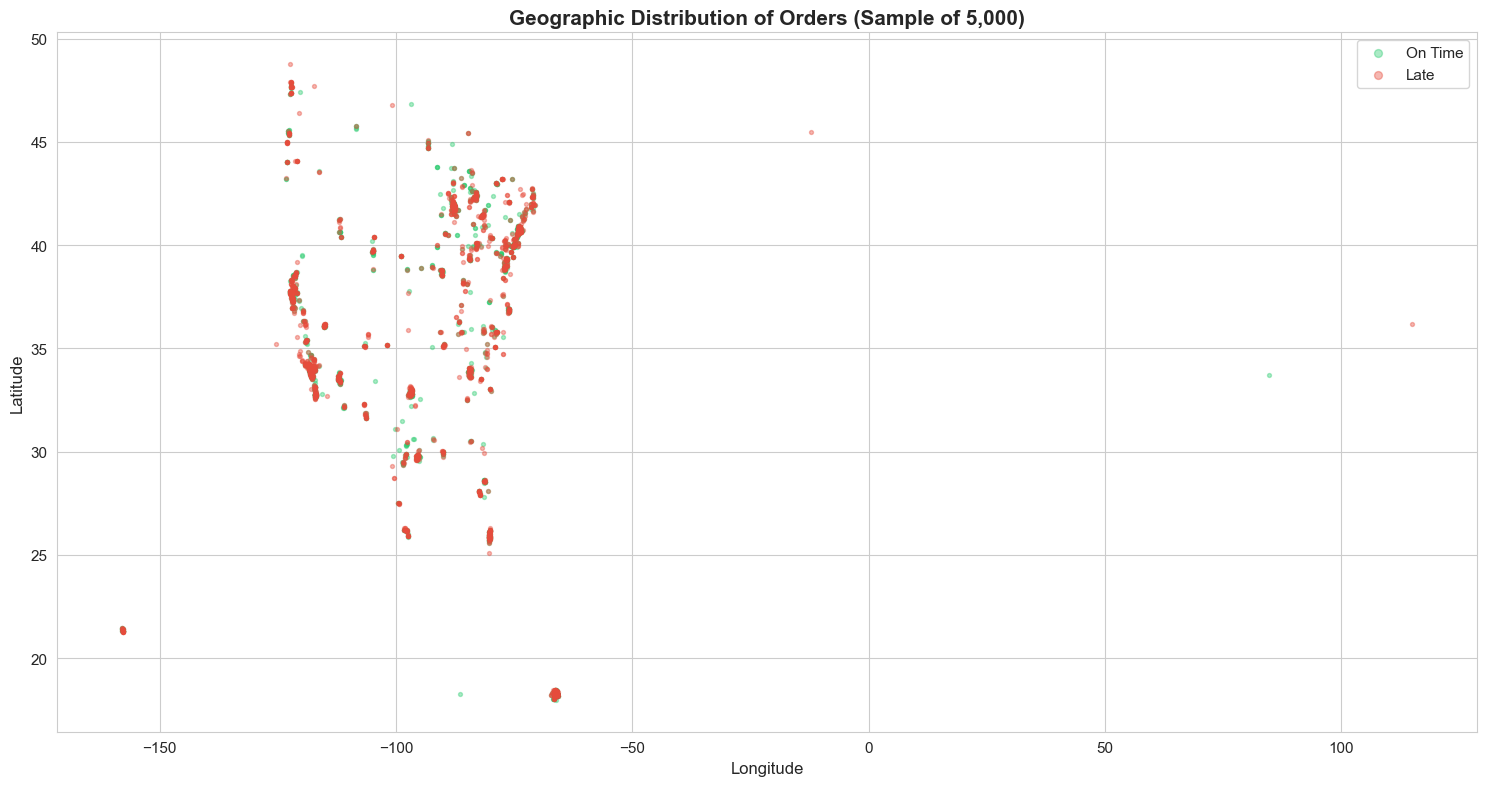


💡 INSIGHT: Visual scan shows late orders concentrated in specific regions
🌟 Power BI tip: This becomes a beautiful map visualization on Page 3


In [13]:
# ===== CHART 11: Geographic Scatter — Where are the Late Orders? =====

fig, ax = plt.subplots(figsize=(15, 8))

# Sample 5000 points for cleaner viz
sample = df.sample(n=min(5000, len(df)), random_state=42)

on_time = sample[sample['Late_delivery_risk'] == 0]
late = sample[sample['Late_delivery_risk'] == 1]

ax.scatter(on_time['Longitude'], on_time['Latitude'], 
           c=COLORS['ontime'], s=8, alpha=0.4, label='On Time')
ax.scatter(late['Longitude'], late['Latitude'], 
           c=COLORS['late'], s=8, alpha=0.4, label='Late')

ax.set_title('Geographic Distribution of Orders (Sample of 5,000)', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=11, markerscale=2)

plt.tight_layout()
plt.savefig('../charts/13_geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Visual scan shows late orders concentrated in specific regions")
print("🌟 Power BI tip: This becomes a beautiful map visualization on Page 3")

In [14]:
# ===== GENERATE EDA INSIGHTS SUMMARY =====

# Recalculate key insights for the summary
shipping_top = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)
market_top = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)
category_top = df[df.groupby('Category Name')['Late_delivery_risk'].transform('count') > 500] \
                  .groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False).head(5)

insights = f"""
PHASE 4 — EDA KEY INSIGHTS
================================================

OVERALL: {df['Late_delivery_risk'].mean()*100:.1f}% of orders are LATE
(This is a serious operational issue requiring intervention)

1. SHIPPING MODE RISK RANKING:
{shipping_top.apply(lambda x: f'{x*100:.1f}%').to_string()}

   → KEY FINDING: Faster shipping modes (First Class, Same Day) have 
     HIGHER late rates because of tighter SLAs to break.

2. MARKET RISK RANKING:
{market_top.apply(lambda x: f'{x*100:.1f}%').to_string()}

   → KEY FINDING: Regional infrastructure & logistics partner quality
     drives the variance across markets.

3. TOP 5 RISKIEST CATEGORIES:
{category_top.apply(lambda x: f'{x*100:.1f}%').to_string()}

4. SCHEDULED SHIPPING DAYS:
   → Shorter scheduled times correlate with higher late rates
   → Operations should review SLA commitments by mode

5. ORDER VALUE PATTERN:
   → Sales and quantity have weak direct correlation with delays
   → Lateness is more about logistics than order size

CHARTS GENERATED: 11 (saved in /charts folder)
READY FOR: Phase 5 — Feature Engineering
"""

print(insights)

with open('../phase4_insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)

print("\n✅ Insights saved to phase4_insights.txt")
print("📁 All 11 charts saved in /charts folder")


PHASE 4 — EDA KEY INSIGHTS

OVERALL: 54.8% of orders are LATE
(This is a serious operational issue requiring intervention)

1. SHIPPING MODE RISK RANKING:
Shipping Mode
First Class       95.3%
Second Class      76.6%
Same Day          45.7%
Standard Class    38.1%

   → KEY FINDING: Faster shipping modes (First Class, Same Day) have 
     HIGHER late rates because of tighter SLAs to break.

2. MARKET RISK RANKING:
Market
Europe          55.2%
Pacific Asia    55.0%
USCA            54.8%
Africa          54.6%
LATAM           54.4%

   → KEY FINDING: Regional infrastructure & logistics partner quality
     drives the variance across markets.

3. TOP 5 RISKIEST CATEGORIES:
Category Name
Cameras             58.1%
Accessories         57.0%
Women's Clothing    56.5%
Golf Gloves         56.3%
Electronics         56.1%

4. SCHEDULED SHIPPING DAYS:
   → Shorter scheduled times correlate with higher late rates
   → Operations should review SLA commitments by mode

5. ORDER VALUE PATTERN:
   → Sa

In [15]:
# Save dataset with the buckets we created (Discount_Bucket, Profit_Bucket)
# We'll use these in Phase 5 for additional feature engineering

df.to_csv('../data/APL_Logistics_eda.csv', index=False, encoding='utf-8')
print(f"✅ EDA dataset saved: APL_Logistics_eda.csv")
print(f"📊 Shape: {df.shape}")

✅ EDA dataset saved: APL_Logistics_eda.csv
📊 Shape: (180519, 26)
